# 环境要求

In [61]:
import sys
print(sys.executable)

!uv pip install --python "{sys.executable}" xgboost scikit-learn matplotlib seaborn shap ipykernel

d:\ML\demos\.venv\Scripts\python.exe


Checked 6 packages in 216ms


uv 可以直接运行上面的代码块

如果是 conda 环境 可以直接把下面这一行复制粘贴覆盖上面的代码块
运行  
 !pip install xgboost scikit-learn matplotlib seaborn shap

## 实验介绍

本实验旨在学习和应用 XGBoost模型,分别完成分类和回归任务,并通过交叉验证与参数调优分析模型性能,同时利用特征重要性解释模型行为.

XGBoost 是一种基于梯度提升树的集成学习算法.其核心思想是通过逐步训练多个决策树来拟合前一轮模型的残差,从而不断提升模型预测能力.

与传统 GBDT 相比,XGBoost 的主要优势包括:

- 引入正则化项,控制模型复杂度,防止过拟合  
- 支持并行计算,提高训练速度  
- 能够处理缺失值  
- 提供特征重要性分析功能  

---

## 参数说明

- max_depth:树的最大深度  
- learning_rate:学习率  
- n_estimators:树的数量  
- subsample:采样比例  


In [62]:
import sys
print(sys.executable)

d:\ML\demos\.venv\Scripts\python.exe


# Part1 分类模型
## 1.导入数据与库
sklearn 提供了数据集加载、数据划分以及模型评估工具
matplotlib 和 seaborn 用于结果可视化
GridSearchCV 用于参数调优。

In [63]:
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import shap

plt.rcParams['axes.unicode_minus'] = False
param_list = ['max_depth', 'learning_rate', 'n_estimators', 'subsample']

## 2. 数据预处理与划分
划分训练集/测试集

In [65]:
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
print(f"数据集形状: {X.shape}")

数据集形状: (150, 4)


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## 3.训练初始模型
训练模型并验证

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



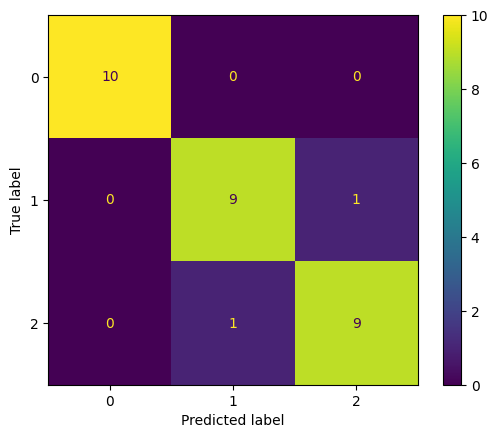

In [68]:
model = xgb.XGBClassifier(eval_metric='mlogloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

precision(精确率):在所有被预测为类别1的样本中，有多少是真的？

recall(召回率):在所有真正属于类别1的样本中，有多少被成功预测？

f1-score(F1分数):精确率和召回率的调和平均数，是一个综合指标

support:每个类别在测试集中真实的样本数量

accuracy:总体准确率

macro avg:各类指标的简单平均

weighted avg:各类指标的加权平均

模型默认参数通常为：

max_depth: 6

learning_rate: 0.3

n_estimators: 100

subsample: 1

## 4.参数调整（网格搜索）

In [69]:
params = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.1, 0.2],
    'n_estimators': [50, 100],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(xgb.XGBClassifier(eval_metric='mlogloss'),
                    param_grid=params,
                    scoring='accuracy',
                    cv=3,
                    verbose=1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}


重新训练

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



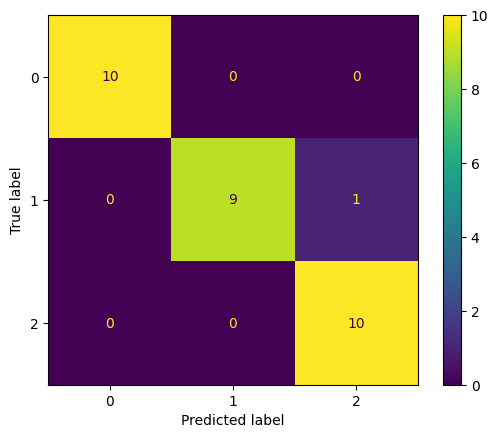

In [70]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

### ROC Curve

为了进一步评估分类模型性能，可以通过 ROC 曲线分析模型在不同阈值下的表现。

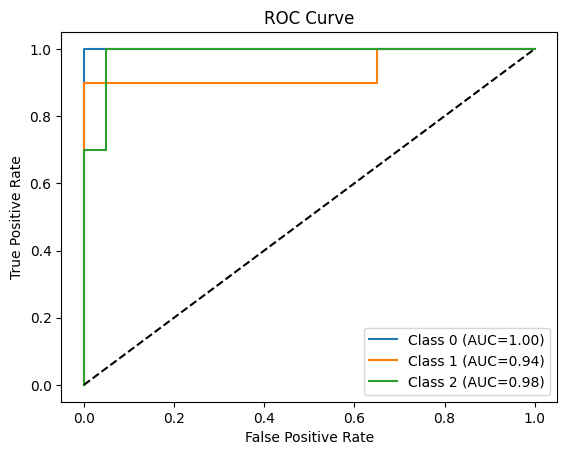

In [71]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# 二值化标签
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = best_model.predict_proba(X_test)

# 计算 ROC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘图
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

从 ROC 曲线可以看出，各类别的曲线均接近左上角，AUC 较高，说明模型具有较好的多分类区分能力。

重要性分析

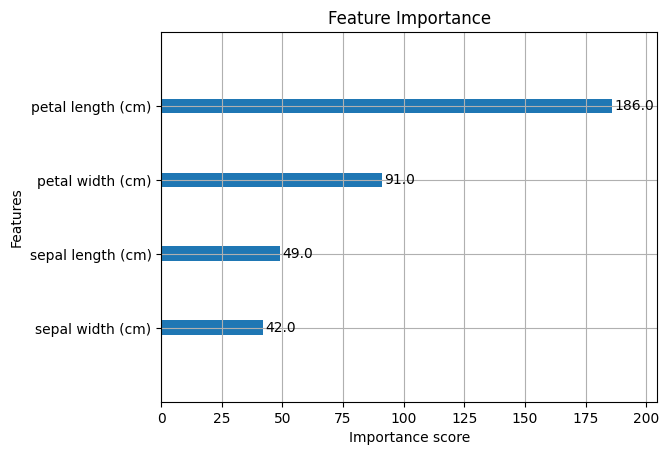

In [72]:
xgb.plot_importance(best_model)
plt.title("Feature Importance")
plt.show()

在本部分中，我们使用 XGBoost 模型对特征的重要性进行分析。

根据 XGBoost 模型计算得到的特征重要性结果如下（按重要性从高到低排序）：

1. **petal length (cm)** – importance = 184  
2. **petal width (cm)** – importance = 91  
3. **sepal length (cm)** – importance = 54  
4. **sepal width (cm)** – importance = 38  

从结果可以看出，petal length 和 petal width 对分类结果的影响最大，而 sepal 相关特征的重要性相对较低。

XGBoost 提供了多种特征重要性评估方式，包括：

- weight：特征被用于做分类判断的次数  
- gain：特征在分类时带来的信息增益（最常用）  
- cover：特征分类时所影响的样本数量  

在实际应用中，通常使用 gain 作为主要指标，根据特征重要性排序选择关键特征。

从实验结果可以看出，不同特征对分类任务的贡献不同，其中重要性较高的特征在模型决策中起到了更关键的作用。

# Part2 回归模型
## 1.导入数据与预处理

In [73]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import root_mean_squared_error, r2_score

# 加载波士顿房价数据
boston = fetch_openml(name='boston', version=1, as_frame=True)
X = pd.DataFrame(boston.data, columns=boston.feature_names)
for col in X.select_dtypes(['category']).columns:
    X[col] = X[col].cat.codes
y = boston.target.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 2.初始模型训练与评估

In [74]:
# 初始模型
reg = xgb.XGBRegressor()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

RMSE: 3.04
R2 Score: 0.88


预测结果可视化

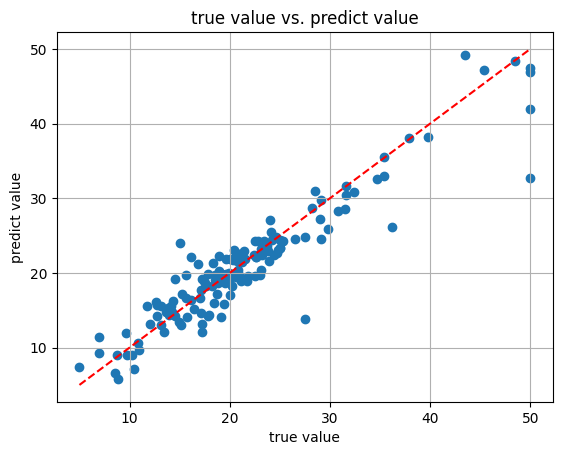

In [75]:
# 回归预测结果可视化
plt.scatter(y_test, y_pred)
plt.xlabel("true value")
plt.ylabel("predict value")
plt.title("true value vs. predict value")
plt.grid(True)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 理想线
plt.show()

## 3.参数调整（网格搜索）

In [76]:
# 参数调优
params = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

grid_reg = GridSearchCV(xgb.XGBRegressor(),
                        param_grid=params,
                        scoring='neg_root_mean_squared_error',
                        cv=3,
                        verbose=1)
grid_reg.fit(X_train, y_train)

print("Best Params:", grid_reg.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


## 4.重新评估最佳模型

In [77]:
# 使用调优后的模型
best_reg = grid_reg.best_estimator_
y_pred_best = best_reg.predict(X_test)

print(f"RMSE: {root_mean_squared_error(y_test, y_pred_best):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_best):.2f}")

RMSE: 2.96
R2 Score: 0.88


绘制散点图

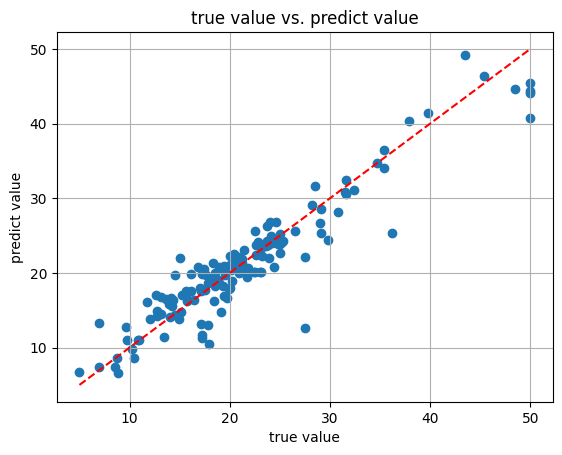

In [78]:
# 回归预测结果可视化
plt.scatter(y_test, y_pred_best)
plt.xlabel("true value")
plt.ylabel("predict value")
plt.title("true value vs. predict value")
plt.grid(True)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 理想线
plt.show()

## 5.特征重要性分析与可视化

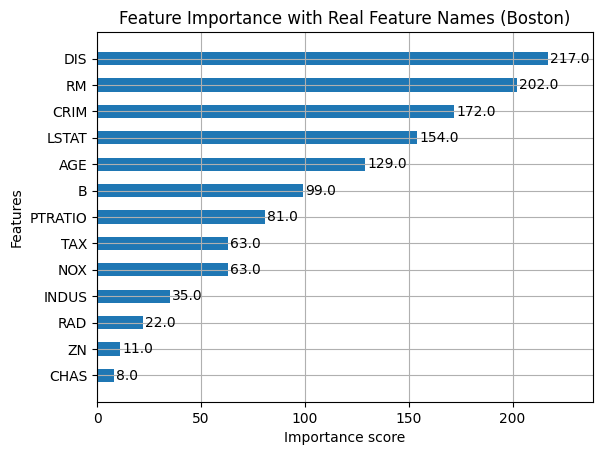

In [83]:
best_reg.get_booster().feature_names = X.columns.tolist()
xgb.plot_importance(best_reg, height=0.5, importance_type='weight')
plt.title("Feature Importance with Real Feature Names (Boston)")
plt.show()

"weight" | 特征被用于分裂的次数（默认） | 频率高说明模型倾向于用这个特征分裂  
"gain" | 每次用该特征分裂带来的 平均增益 | 衡量贡献大小，常更有参考价值  
"cover" | 使用该特征时，命中的样本数（覆盖度） | 衡量该特征“影响”的样本多不多  

SHAP分析

In [86]:
import shap

explainer = shap.TreeExplainer(best_reg)

# 计算测试集的 SHAP 值
shap_values = explainer(X_test)

# 可视化一：summary_plot，展示特征影响力 + 分布
shap.summary_plot(shap_values, X_test, plot_type='bar')  # 条形图
shap.summary_plot(shap_values, X_test)  # 带颜色密度点图

ValueError: could not convert string to float: '[2.301582E1]'